## Raport 2
Adam Freń, Karol Garbaczewski

In [3]:
import numpy as np
import scipy.stats
import matplotlib.pyplot as plt

### 1.
Z populacji generalnej o rozkładzie normalnym $N (\mu, \sigma = 0.2)$ pobrano próbę (dane dołączone do
listy). Dla $\alpha$ = 0.05 zweryfikuj hipotezy
+ $\mu \ne 1.5$
+  $\mu < 1.5$
+  $\mu > 1.5$ 

Narysuj odpowiednie obszary kytyczne i wyznacz p-wartości dla każdej z powyższych hipotez. Odpo-
wiedz na pytanie co stanie się kiedy zwiększymy bądź zmniejszymy poziom ufności.
Przyjmujemy że hipoteza zerowa tutaj jest równa $H_0: \mu = 1.5$

In [4]:
plik=open("./lista7zad1.txt",'r')
p=plik.read()
p=p.split(",")
N=1_000_000
for i in range(len(p)):
    p[i] = float(p[i])

sigma=0.2
x_dash=np.mean(p)   
Z=x_dash
alpha=0.05
left_crit=(-1)*scipy.stats.norm.ppf(q=1-alpha,loc=0,scale=1)
right_crit=scipy.stats.norm.ppf(q=1-alpha,loc=0,scale=1)
both_crit=scipy.stats.norm.ppf(q=1-(alpha/2),loc=0,scale=1)
mu=1.5
Z=(Z-mu)/(sigma/np.sqrt(len(p)))
t=np.linspace(-3,3,500)

Dla hipotezy alternatywnej $\mu \ne 1.5$ (test obustronny)

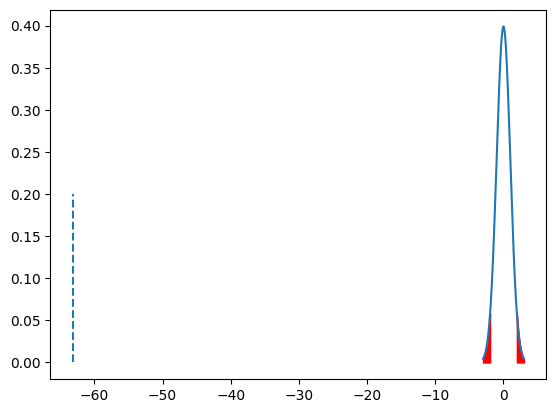

Wartość p: 0.0


In [5]:
pdf_draw=[scipy.stats.norm.pdf(x) for x in t]
plt.plot(t,pdf_draw)
plt.fill_between(x=t,y1=pdf_draw,where = (t<-both_crit),color='r')
plt.fill_between(x=t,y1=pdf_draw,where = (t>both_crit),color='r')
plt.vlines(Z,0,0.2, linestyle="--")
plt.show()
p_value=2*scipy.stats.norm.sf(abs(Z))
print("Wartość p:",p_value)

Statystyka Z wpada w obszar krytyczny,więc odrzucamy hipotezę zerową i nie ma podstaw do odrzucenia hipotezę alternatywną.

Dla hipotezy alternatywnej $\mu < 1.5$ (test lewostronny)

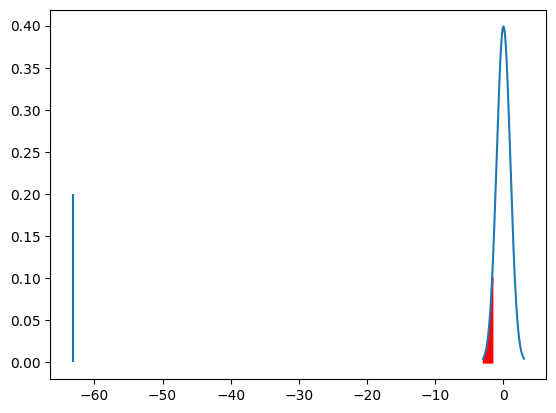

Wartość p: 0.0


In [6]:
plt.plot(t,pdf_draw)
plt.fill_between(x=t,y1=pdf_draw,where = (t<left_crit),color='r')
plt.vlines(Z,0,0.2)
plt.show()
p_value=scipy.stats.norm.cdf(Z)
print("Wartość p:",p_value)

Statystyka Z wpada w obszar krytyczny,więc odrzucamy hipotezę zerową i możemy przyjąć hipotezę alternatywną.

Dla hipotezy alternatywnej $\mu > 1.5$ (test prawostronny)

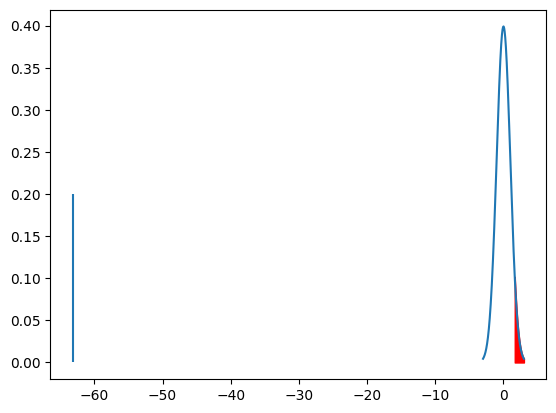

Wartość p: 1.0


In [7]:
plt.plot(t,pdf_draw)
plt.fill_between(x=t,y1=pdf_draw,where = (t>right_crit),color='r')
plt.vlines(Z,0,0.2)
plt.show()
p_value=scipy.stats.norm.sf(Z)
print("Wartość p:",p_value)

Statystyka Z wpada w obszar krytyczny,więc odrzucamy hipotezę alternatywną i możemy przyjąć hipotezę zerową.

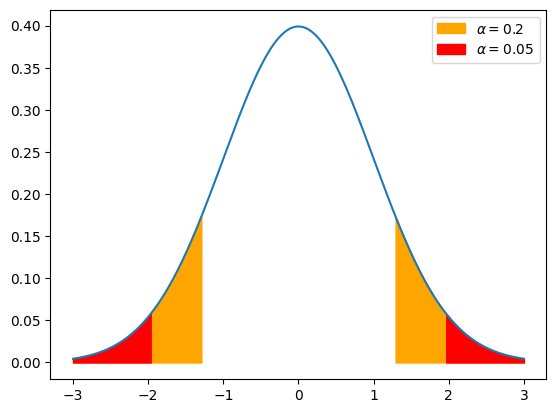

In [8]:
plt.plot(t,pdf_draw)
alpha=0.2
both_crit=scipy.stats.norm.ppf(q=1-(alpha/2),loc=0,scale=1)
plt.fill_between(x=t,y1=pdf_draw,where = (t<-both_crit),color='orange',label=r"$\alpha = 0.2$")
plt.fill_between(x=t,y1=pdf_draw,where = (t>both_crit),color='orange')
alpha=0.05
both_crit=scipy.stats.norm.ppf(q=1-(alpha/2),loc=0,scale=1)
plt.fill_between(x=t,y1=pdf_draw,where = (t<-both_crit),color='r',label=r"$\alpha = 0.05$")
plt.fill_between(x=t,y1=pdf_draw,where = (t>both_crit),color='r')
plt.legend()
plt.show()

Z wykresu widać że wraz ze wzrostem $\alpha$ obszar krytyczny się zwiększa.Dokładnie takie samo zachowanie obserwujemy w testach jednostronnych

## 2.

W zadaniu drugim odrazu policzmy pod każdą hipotezą prawdopodobieństwa błęów I i II rodzaju. Podobnie jak w zadaniu 1. jeśli zwiększymy $\alpha$ zwiększymy obszar krytyczny dla którego odrzucamy hipotezę zerową. Wykres powyżej bardzo dobrze oddaje intuicję.

In [153]:
plik =open("lista7zad2.txt", "r")
p = plik.read()
p = p.split(",")
dane = np.zeros(len(p))
for i in range(len(p)):
    dane[i] = float(p[i])

print(len(dane))

1000


# $H_{1}:\quad \sigma \neq 1.5$ 

In [ ]:
# H0 = wariancja = 1,5
# H1 wariancja != 1,5

# statystyka chisquare dla naszej próbki 
h0_var = 1.5
srednia_populacji = 0.2
n = len(dane)
alfa = 0.05

# Estymator s2

# znamy naszą średnią populacji więc mamy n -stopni swobody
chi_probka = np.sum((dane - srednia_populacji)**2) / h0_var
chi_left = scipy.stats.chi2.ppf(alfa/2,df=n)
chi_right = scipy.stats.chi2.ppf(1-alfa/2, df=n)
p_value = 2 * min(scipy.stats.chi2.cdf(chi_probka, df=n),scipy.stats.chi2.sf(chi_probka, df=n) )
print(p_value)
# wiemy że nasz estymator ma rozkład chi-2 z n-1 stopniami swobody
# liczymy kwantyle dla poz. istotnosci 1-alfa


2558.6531476205023
914.257153799259
1089.5309127749135
8.076063894477226e-137


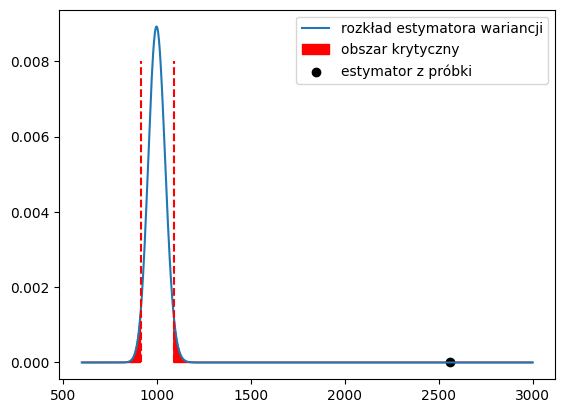

In [162]:
argumenty = np.linspace(600,3000, 1000)

plt.plot(argumenty, scipy.stats.chi2.pdf(argumenty, df=n), label="rozkład estymatora wariancji")
plt.vlines([chi_left, chi_right], ymin=0, ymax=0.008, linestyles="--", color="red")
plt.fill_between(x=argumenty,y1=scipy.stats.chi2.pdf(argumenty, df=n),where = (argumenty < chi_left) | (argumenty > chi_right),color='r', label="obszar krytyczny")
plt.scatter(chi_probka, 0, color="black", label="estymator z próbki")
plt.legend()


### Prawdopodobieństwo popełnienia błędów 1-2 rodzaju

In [163]:
# 1 rodzaj odrzucamy hipotezę zerową gdy jest prawdziwa
# 2 rodzaj przyjmujemy hipotezę zerową gdy jest fałszywa

# 1 
trials = 1000
rejected = 0
for i in range(trials):
    sample = np.random.normal(loc=0.2, scale=np.sqrt(1.5), size=1000)
    chi_sample = np.sum((sample - srednia_populacji)**2)/h0_var
    if chi_left > chi_sample or chi_sample > chi_right:
        rejected += 1
print(f"błąd 1-szego rodzaju {rejected/trials}")

# 2 
# sprawdzimy błąd 2. rodzaju dla kilku wartości 
alternatives = [0.1, 1.3, 1.6]

for var in alternatives:
    accepted = 0
    for i in range(trials):
        sample = np.random.normal(loc=0.2, scale=np.sqrt(var), size=1000)
        chi_sample = np.sum((sample - srednia_populacji)**2)/h0_var
        if chi_left < chi_sample < chi_right:
            accepted += 1
    print(f"bład 2. rodzaju dla wariancji {var} wynosi: {accepted/trials}, moc testu: {1-accepted/trials}")


błąd 1-szego rodzaju 0.053
bład 2. rodzaju dla wariancji 0.1 wynosi: 0.0, moc testu: 1.0
bład 2. rodzaju dla wariancji 1.3 wynosi: 0.126, moc testu: 0.874
bład 2. rodzaju dla wariancji 1.6 wynosi: 0.66, moc testu: 0.33999999999999997


Odrzucamy hipotezę zerową na rzecz hipotezy alternatywnej n poziomie istotności 0.05. 

# $ H_{1}: \quad  \alpha > 1.5 $

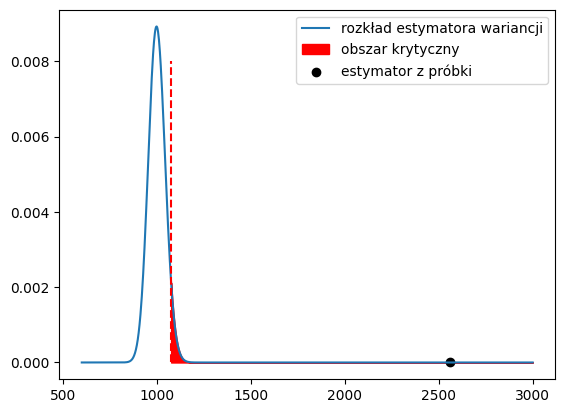

In [164]:
chi_right = scipy.stats.chi2.ppf(1-alfa, df=n)
p_value = scipy.stats.chi2.sf(chi_probka, df=n)

plt.plot(argumenty, scipy.stats.chi2.pdf(argumenty, df=n), label="rozkład estymatora wariancji")
plt.vlines( chi_right, ymin=0, ymax=0.008, linestyle="--", color="red")
plt.fill_between(x=argumenty,y1=scipy.stats.chi2.pdf(argumenty, df=n),where =(argumenty > chi_right), color='r', label="obszar krytyczny")
plt.scatter(chi_probka, 0, color="black", label="estymator z próbki")
plt.legend()

### Prawdopodobieństwa popełnienia błędów I. i II. rodzaju

In [168]:

# 1 
trials = 1000
rejected = 0
for i in range(trials):
    sample = np.random.normal(loc=0.2, scale=np.sqrt(1.5), size=1000)
    chi_sample = np.sum((sample - srednia_populacji)**2)/h0_var
    if chi_left > chi_sample or chi_sample > chi_right:
        rejected += 1
print(f"błąd 1-szego rodzaju {rejected/trials}")

# 2 
# sprawdzimy błąd 2. rodzaju dla kilku wartości 
alternatives = [1.6, 1.7, 1.9]

for var in alternatives:
    accepted = 0
    for i in range(trials):
        sample = np.random.normal(loc=0.2, scale=np.sqrt(var), size=1000)
        chi_sample = np.sum((sample - srednia_populacji)**2)/h0_var
        if chi_left < chi_sample < chi_right:
            accepted += 1
    print(f"bład 2. rodzaju dla wariancji {var} wynosi: {accepted/trials}, moc testu: {1-accepted/trials}")

błąd 1-szego rodzaju 0.098
bład 2. rodzaju dla wariancji 1.6 wynosi: 0.591, moc testu: 0.40900000000000003
bład 2. rodzaju dla wariancji 1.7 wynosi: 0.119, moc testu: 0.881
bład 2. rodzaju dla wariancji 1.9 wynosi: 0.0, moc testu: 1.0


### Interpretacja
Wartość estymatora wpada do obszaru krytycznego, odrzucamy hipotezę zerową ną rzecz hipotezy alternatywnej, na poziomie istotności 0.05.

# $ H_{1}: \quad  \alpha < 1.5 $

1.0 p-value


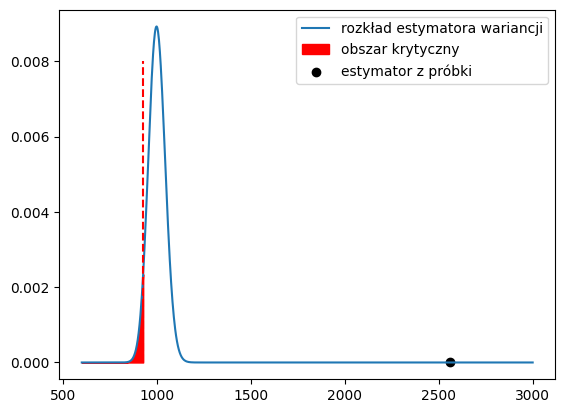

In [179]:
chi_left = scipy.stats.chi2.ppf(alfa,df=n)
p_value = scipy.stats.chi.cdf(chi_probka, df=n)
print(p_value, "p-value")

plt.plot(argumenty, scipy.stats.chi2.pdf(argumenty, df=n), label="rozkład estymatora wariancji")
plt.vlines( chi_left, ymin=0, ymax=0.008, linestyle="--", color="red")
plt.fill_between(x=argumenty,y1=scipy.stats.chi2.pdf(argumenty, df=n),where =(argumenty < chi_left), color='r', label="obszar krytyczny")
plt.scatter(chi_probka, 0, color="black", label="estymator z próbki")
plt.legend()
# Przyjmujemy hipotezę alternatywną 


### Prawdopodobieństwo popełnienia błędów I i II. rodzaju 

In [180]:

# 1 
trials = 1000
rejected = 0
for i in range(trials):
    sample = np.random.normal(loc=0.2, scale=np.sqrt(1.5), size=1000)
    chi_sample = np.sum((sample - srednia_populacji)**2)/h0_var
    if chi_left > chi_sample or chi_sample > chi_right:
        rejected += 1
print(f"błąd 1-szego rodzaju {rejected/trials}")

# 2 
# sprawdzimy błąd 2. rodzaju dla kilku wartości 
alternatives = [0.001, 0.9, 1.2, 1.3, 1.4]

for var in alternatives:
    accepted = 0
    for i in range(trials):
        sample = np.random.normal(loc=0.2, scale=np.sqrt(var), size=1000)
        chi_sample = np.sum((sample - srednia_populacji)**2)/h0_var
        if chi_left < chi_sample < chi_right:
            accepted += 1
    print(f"bład 2. rodzaju dla wariancji {var} wynosi: {accepted/trials}, moc testu: {1-accepted/trials}")

błąd 1-szego rodzaju 0.114
bład 2. rodzaju dla wariancji 0.001 wynosi: 0.0, moc testu: 1.0
bład 2. rodzaju dla wariancji 0.9 wynosi: 0.0, moc testu: 1.0
bład 2. rodzaju dla wariancji 1.2 wynosi: 0.0, moc testu: 1.0
bład 2. rodzaju dla wariancji 1.3 wynosi: 0.066, moc testu: 0.9339999999999999
bład 2. rodzaju dla wariancji 1.4 wynosi: 0.545, moc testu: 0.45499999999999996


### Interpretacja 
Przyjmujemy hipotezę zerową. 

### 3.
Dla hipotez z zadań 1-2 wyznacz symulacyjnie prawdopodobieństwa popełnienia błędów I i II rodzaju.
Sprawdź moce testów.

In [181]:
mu=1.5
sigma=0.2
Z_vect=[]
alpha=0.05
N=1000
for i in range(10_000):
    T=np.random.normal(mu,sigma,N)
    Z=np.mean(T)-mu
    Z=Z/((sigma)/(np.sqrt(N)))
    Z_vect.append(Z)
left_probab=0
right_probab=0
both_probab=0    
counter=0
for z in Z_vect:

    if scipy.stats.norm.cdf(z)<alpha:
        left_probab+=1
    if scipy.stats.norm.sf(z)<alpha:
        right_probab+=1
    if 2*scipy.stats.norm.sf(abs(z))<alpha:
        both_probab+=1
    counter+=1
print("Prawdopodobieństwo błędu I rodzaju:")
print("Test lewostronny:",left_probab/counter)
print("Test prawostronny:",right_probab/counter)
print("Test obustronny:",both_probab/counter)


Prawdopodobieństwo błędu I rodzaju:
Test lewostronny: 0.0485
Test prawostronny: 0.0507
Test obustronny: 0.0503


Dla podanego przykładu (N=1000) prawdopodobieństwo błędu 1 rodzaju wynosi 
+ dla testu lewostronnego: $\sim$ 0.05
+ dla testu prawostronnego: $\sim$  0.05
+ dla test obustronnego: $\sim$  0.05
Prawdopodobieństwo błędu jest tak niskie ponieważ wariancja rozkładu jest niska

In [ ]:
M=100_000
mu=1.5
R=np.random.uniform(-0.3,0.3,M)
mu_0=[mu]
sigma=0.2
Z_vect=[]
alpha=0.05
N=1000
for i in range(M):
    T=np.random.normal(mu,sigma,N)
    Z=np.mean(T)-mu+R[i] # czemu dodajesz R[i]?
    Z=Z/((sigma)/(np.sqrt(N)))
    Z_vect.append(Z)
left_probab=0
right_probab=0
both_probab=0    
counter=0
for i in range(len(Z_vect)):
    if scipy.stats.norm.cdf(Z_vect[i])>alpha:
            left_probab+=1
    if scipy.stats.norm.sf(Z_vect[i])>alpha:
            right_probab+=1
    if 2*scipy.stats.norm.sf(abs(Z_vect[i]))>alpha:
        both_probab+=1
    counter+=1
print("Prawdopodobieństwo błędu II rodzaju:")
print("Test lewostronny:",left_probab/counter)
print("Test prawostronny:",right_probab/counter)
print("Test obustronny:",both_probab/counter)


Prawdopodobieństwo błędu II rodzaju:
Test lewostronny: 0.5186
Test prawostronny: 0.51607
Test obustronny: 0.0413


Dla podanego przykładu (N=1000) prawdopodobieństwo błędu 2 rodzaju wynosi 
+ dla testu lewostronnego: $\sim$ 0.5
+ dla testu prawostronnego: $\sim$  0.5
+ dla test obustronnego: $\sim$  0.05

# v Do Przepisania inaczej !!!!

prawdopodobieństwa dla lewostronnego i prawostronnego są tak wysokie ponieważ to, że test nie wpada w "połowiczny" przedział ufności nie oznacza, że jest bliski zadanej średniej

# ^ Do Przepisania inaczej !!!!